# Multiagent Pattern - Multiagent Collaboration

<img src="../img/multiagent_pattern.png" alt="Alt text" width="500"/>

---

You may have heard about frameworks like [CrewAI](https://www.crewai.com/) or [AutoGen](https://microsoft.github.io/autogen/0.2/), which allow you to create multi-agent applications.

These frameworks implement different variations of the multi-agent pattern, in which tasks are divided into **smaller subtasks executed by different roles** (e.g. one agent can be a software engineer, another a project manager, etc.)

For this final lesson, I wanted to build something more elaborate. That's why I've been working on a 𝐦𝐢𝐧𝐢𝐦𝐚𝐥𝐢𝐬𝐭 𝐯𝐞𝐫𝐬𝐢𝐨𝐧 𝐨𝐟 𝐂𝐫𝐞𝐰𝐀𝐈, drawing inspiration from two of its key concepts: 𝐂𝐫𝐞𝐰 and 𝐀𝐠𝐞𝐧𝐭.

Additionally, I've also borrowed ideas from [𝐀𝐢𝐫𝐟𝐥𝐨𝐰](https://airflow.apache.org/)'𝐬 𝐝𝐞𝐬𝐢𝐠𝐧 𝐩𝐡𝐢𝐥𝐨𝐬𝐨𝐩𝐡𝐲, using >> and << to define dependencies between my agents. In this micro-CrewAI, 𝐚𝐠𝐞𝐧𝐭𝐬 are equivalent to 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐓𝐚𝐬𝐤𝐬 and the 𝐂𝐫𝐞𝐰 is equivalent to an 𝐀𝐢𝐫𝐟𝐥𝐨𝐰 𝐃𝐀𝐆.

Take a look at the previous lessons if you haven't!

* [First Lesson: The Reflection Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/reflection_pattern.ipynb)
* [Second Lesson: The Tool Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/tool_pattern.ipynb)
* [Third Lesson: The Planning Pattern](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/planning_pattern.ipynb)

**Let's begin!!** 💪

## The Agent Class

First of all, we need an **Agent Class**. This class implements an
Agent, and internally it implements the ReAct technique (check [Lesson 3](https://github.com/neural-maze/agentic_patterns/blob/main/notebooks/planning_pattern.ipynb) if you want to see this technique in detail!).

In [3]:
import os
import sys
sys.path.append(os.path.abspath("../src"))

In [4]:
from agentic_patterns.multiagent_pattern.agent import Agent

Let's create some example agent, to see how it works.

In [5]:
agent_example = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
)

In [6]:
print(agent_example.run())

In the depths of existence, a question resounds,
A mystery that echoes, without a bound.
The meaning of life, a puzzle to share,
A riddle that whispers, with no single care.

Some search for answers, in the stars up high,
Others in the silence, of a quiet sigh.
In the beauty of nature, or the beat of the heart,
The meaning of life, a journey to start.

It's a path that unwinds, through joy and through strife,
A dance with the shadows, and the light of life.
It's the love that we give, the tears that we cry,
The memories we cherish, the moments that fly.

In the stillness of night, or the chaos of day,
The meaning of life, is found in our own way.
It's the fire that burns, the passion that drives,
The dreams that we pursue, the spirit that thrives.

It's a question that haunts, a mystery that beckons,
A journey that winds, through the labyrinth ofreckonings.
Yet, in the end, it's not the answer we seek,
But the journey itself, that makes life unique.


You can also associate tools with the agent. Let's create a tool for writing some string into a CSV.

In [7]:
from agentic_patterns.tool_pattern.tool import tool

In [8]:
@tool
def write_str_to_txt(string_data: str, txt_filename: str):
    """
    Writes a string to a txt file.

    This function takes a string and writes it to a text file. If the file already exists, 
    it will be overwritten with the new data.

    Args:
        string_data (str): The string containing the data to be written to the file.
        txt_filename (str): The name of the text file to which the data should be written.
    """
    # Write the string data to the text file
    with open(txt_filename, mode='w', encoding='utf-8') as file:
        file.write(string_data)

    print(f"Data successfully written to {txt_filename}")

In [12]:
agent_tool_example = Agent(
    name="Writer Agent",
    backstory="You are a language model specialised in writing text into .txt files",
    task_description="Write the string 'This is a Tool Agent Simon' into './tool_agent_example.txt'",
    task_expected_output="A .txt file containing the given string",
    tools=write_str_to_txt,
)

In [13]:
agent_tool_example.run()


Thought: I need to write the given string to a .txt file.

Using Tool: write_str_to_txt

Tool call dict: 
{'name': 'write_str_to_txt', 'arguments': {'string_data': 'This is a Tool Agent Simon', 'txt_filename': './tool_agent_example.txt'}, 'id': 0}
Data successfully written to ./tool_agent_example.txt

Tool result: 
None

Observations: {0: None}


"A .txt file containing the string 'This is a Tool Agent Simon' has been created in './tool_agent_example.txt'"

## Defining Agent Dependencies

Let's define two agents now.

In [14]:
agent_1 = Agent(
    name="Poet Agent",
    backstory="You are a well-known poet, who enjoys creating high quality poetry.",
    task_description="Write a poem about the meaning of life",
    task_expected_output="Just output the poem, without any title or introductory sentences",
)

agent_2 = Agent(
    name="Poem Translator Agent",
    backstory="You are an expert translator especially skilled in Ancient Greek",
    task_description="Translate a poem into Ancient Greek", 
    task_expected_output="Just output the translated poem and nothing else"
)

We can define the agent dependencies using the `>>` operator.

In [15]:
agent_1 >> agent_2

Poem Translator Agent

This means `agent_2` depends on `agent_1`. We can check the dependencies and dependents of both agents.

In [16]:
print("Agent 1 dependencies: ", agent_1.dependencies)
print("Agent 1 dependents: ", agent_1.dependents)
print("Agent 2 dependencies: ", agent_2.dependencies)
print("Agent 2 dependents: ", agent_2.dependents)

Agent 1 dependencies:  []
Agent 1 dependents:  [Poem Translator Agent]
Agent 2 dependencies:  [Poet Agent]
Agent 2 dependents:  []


Now, if we run `agent_1`, the results will be added to `agent_2`'s context.

In [17]:
print(agent_1.run())

In the grand tapestry of existence, we're a thread,
A fleeting moment, a whispered word, a breath.
A dance of atoms, a spark of life, a flame,
That flickers bright, and then is lost in the game.

We search for meaning, a purpose to our strife,
A reason to awaken, to live, to love, to thrive.
We chase the wind, we grasp the air,
And yet, the answer lies, beyond the snares.

In the beauty of a sunrise, in the stars up high,
In the laughter of a child, in the tears we've cried.
In the warmth of love, in the comfort of a friend,
We find the meaning, that will never end.

It's not a destination, but a journey we undertake,
A path that winds, a road that turns, a mistake.
It's the moments we share, the memories we hold,
The love we give, the love we're told.

In the silence, we find the voice,
A whisper that guides, a choice.
To live, to love, to let go,
To find the meaning, as the moments flow.


In [18]:
print(agent_2.context)

Poem Translator Agent received context: 
In the grand tapestry of existence, we're a thread,
A fleeting moment, a whispered word, a breath.
A dance of atoms, a spark of life, a flame,
That flickers bright, and then is lost in the game.

We search for meaning, a purpose to our strife,
A reason to awaken, to live, to love, to thrive.
We chase the wind, we grasp the air,
And yet, the answer lies, beyond the snares.

In the beauty of a sunrise, in the stars up high,
In the laughter of a child, in the tears we've cried.
In the warmth of love, in the comfort of a friend,
We find the meaning, that will never end.

It's not a destination, but a journey we undertake,
A path that winds, a road that turns, a mistake.
It's the moments we share, the memories we hold,
The love we give, the love we're told.

In the silence, we find the voice,
A whisper that guides, a choice.
To live, to love, to let go,
To find the meaning, as the moments flow.


Now, if we run the second agent, it will use the context received from the previous agent to generate its output.

In [19]:
print(agent_2.run())

Ἐν τῇ μεγάλῃ τοῦ ὄντος tapēti, θρῆνος εἰμεν,
Μία ὀλίγη στιγμή, λόγος ψηφιδωτὸς, πνοή.
Χορὸς ἀτόμων, σπινθήρ ζωῆς, φλόγα,
Ἅη φαίνεται λαμπρὰ καὶ τότε ἀπόλλυται ἐν τῷ παίγνιον.

Ζητοῦμεν τὸ νόημα, σκοπὸν τῆς ἡμῶν Polemō,
Λόγον ἐγρήγορσις, ζῆν, ἀγαπᾶν, θρῆνος.
Διώκομεν τὸν ἄνεμον, πιάζομεν τὸν ἀέρα,
Καὶ ἔτι, ἡ ἀπάντηση κείτại, πέρα τῶν παγίδων.

Ἐν τῇ ὡραιότητι τοῦ ἡλίου ἀνατολῆς, ἐν τοῖς ἄστροις ἄνω,
Ἐν τῷ γέλωτι τοῦ παίδos, ἐν ταῖς δακρύσι ἃ ἔκλαυσαμεν.
Ἐν τῇ θερμότητι τῆς ἀγάπης, ἐν τῇ παρηγορίᾳ τοῦ φίλου,
Εὑρίσκομεν τὸ νόημα, ὃ οὐδεπότη οὔ_pot' ἔσται.

Οὐκοῦν τὸ τέλoς, ἀλλά τις ὁδὸς ἣν ἀναλαμβάνομεν,
Παθεῖεν ὁδòς πoικιλὴ, δρόmoς στροφῆς, ἁμαρτία.
Τὰ μoιραῖα κοιν⌒νoῦμεν, μvημoσύvη ἃ κεκτήμεθα,
Ἡ ἀγάπη ἣν διδoμέν, ἡ ἀγάπη ἣν λεγόμεν.

Ἐν τῇ σιγῇ, εὑρίσκομεν τὴν φωνήν,
Ψήφoς ἣ ὁδηγεῖ, προαίρεσις.
Ζῆν, ἀγαπᾶν, ἀφίημι,
Εὑρῆσαι τὸ νόημα, ἃ τὰ μoιραῖα ῥέoσι.


## The Crew

In [20]:
from agentic_patterns.multiagent_pattern.crew import Crew

In [21]:
with Crew() as crew:
    agent_1 = Agent(
        name="Poet Agent",
        backstory="You are a well-known poet, who enjoys creating high quality poetry.",
        task_description="Write a poem about the meaning of life",
        task_expected_output="Just output the poem, without any title or introductory sentences",
    )

    agent_2 = Agent(
        name="Poem Translator Agent",
        backstory="You are an expert translator especially skilled in Spanish",
        task_description="Translate a poem into Spanish", 
        task_expected_output="Just output the translated poem and nothing else"
    )

    agent_3 = Agent(
        name="Writer Agent",
        backstory="You are an expert transcriber, that loves writing poems into txt files",
        task_description="You'll receive a Spanish poem in your context. You need to write the poem into './poem.txt' file",
        task_expected_output="A txt file containing the greek poem received from the context",
        tools=write_str_to_txt,
    )

    agent_1 >> agent_2 >> agent_3

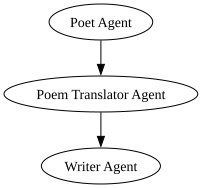

In [22]:
crew.plot()

In [24]:
crew.run()


RUNNING AGENT: Poet Agent

In the grand tapestry of time and space,
A thread of existence, a fleeting pace,
We dance, we weave, we search, we roam,
Seeking answers to life's eternal home.

A question asked, a mystery to share,
The meaning of life, beyond compare,
Is it in love, in joy, in strife, in pain,
Or is it something more, a hidden gain?

In whispers of the wind, in waves of the sea,
In stars up high, in you and me,
A spark of purpose, a flame that burns,
Guiding us forward, through life's concerns.

Through trials and tribulations we find,
The strength to carry on, to leave behind,
The fears, the doubts, the uncertainties of the past,
And forge a new path, where love will forever last.

In the beauty of nature, in the beauty of the soul,
We find the meaning, our hearts made whole,
A sense of belonging, a sense of being,
Connected to all, in the grand symphony of living.

And when our time on this earth is done,
And the journey of life is won,
We'll look back on the moments we'